# Heart Disease Prediction using Machine Learning

## 1. Introduzione

Le malattie cardiovascolari rappresentano una delle principali cause di mortalità a livello mondiale. Una diagnosi precoce può contribuire significativamente a migliorare la qualità della vita dei pazienti e ad aumentare le probabilità di successo dei trattamenti medici.

Negli ultimi anni le tecniche di Machine Learning hanno dimostrato di poter supportare il personale sanitario nell'identificazione di pazienti a rischio, attraverso l'analisi di dati clinici raccolti durante visite ed esami diagnostici.

L'obiettivo di questo progetto è sviluppare e confrontare diversi modelli di classificazione supervisionata in grado di prevedere la presenza di una malattia cardiaca a partire da informazioni cliniche e fisiologiche dei pazienti.

Per lo sviluppo degli esperimenti è stato utilizzato il dataset "Heart Disease" disponibile presso l'UCI Machine Learning Repository. Tale dataset contiene informazioni raccolte da diversi ospedali e rappresenta uno dei dataset più utilizzati nella letteratura scientifica per la valutazione di algoritmi di classificazione applicati all'ambito medico.

In particolare, verranno svolte le seguenti attività:

- Analisi esplorativa del dataset;
- Studio delle caratteristiche delle feature;
- Riduzione della dimensionalità mediante PCA;
- Addestramento di diversi algoritmi di classificazione;
- Valutazione delle prestazioni mediante metriche standard;
- Analisi delle matrici di confusione e delle curve ROC;
- Interpretazione dei risultati tramite tecniche di Explainable AI.

Lo scopo finale consiste nell'individuare il modello in grado di fornire le migliori prestazioni predittive e comprendere quali variabili influenzano maggiormente la presenza di patologie cardiache.

## 1.1 Descrizione del Dataset

Il dataset Heart Disease è stato raccolto e pubblicato all'interno dell'UCI Machine Learning Repository.

Il dataset completo contiene 76 attributi clinici, tuttavia la maggior parte degli studi scientifici utilizza una selezione ridotta di variabili considerate maggiormente significative. In particolare, il dataset Cleveland rappresenta la versione più utilizzata nelle applicazioni di Machine Learning.

Il problema affrontato è di tipo Classification, ovvero un problema di classificazione supervisionata.

La variabile target indica la presenza o meno di una patologia cardiaca:

- 0 → assenza di malattia cardiaca
- 1,2,3,4 → presenza di malattia cardiaca

Nella maggior parte degli studi il problema viene trasformato in una classificazione binaria:

- 0 → nessuna malattia
- 1 → presenza di malattia

Il dataset contiene:

- 303 osservazioni
- 13 feature predittive
- 1 variabile target
- Variabili numeriche e categoriche

Le informazioni raccolte riguardano caratteristiche anagrafiche e parametri clinici dei pazienti, quali età, sesso, pressione sanguigna, colesterolo, frequenza cardiaca massima raggiunta e altri indicatori diagnostici utilizzati in cardiologia.

In [3]:
# Import delle librerie principali

import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import seaborn as sns

# configurazione grafici
sns.set_style("whitegrid")

# visualizzazione completa colonne
pd.set_option("display.max_columns", None)

## 2.1 Caricamento del Dataset

Il dataset viene scaricato direttamente dall'UCI Machine Learning Repository utilizzando la libreria `ucimlrepo`.

In [4]:
# Download dataset

heart_disease = fetch_ucirepo(id=45)

# Features
X = heart_disease.data.features

# Target
y = heart_disease.data.targets

## 2.2 Analisi preliminare del Dataset

Prima di procedere con la costruzione dei modelli è necessario comprendere la struttura del dataset, verificando:

- numero di osservazioni;
- numero di feature;
- tipo delle variabili;
- presenza di eventuali valori mancanti.

In [5]:
print("Numero osservazioni:", X.shape[0])
print("Numero feature:", X.shape[1])

print("\nFeature disponibili:")
print(X.columns.tolist())

Numero osservazioni: 303
Numero feature: 13

Feature disponibili:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [8]:
print(heart_disease.metadata)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [9]:
df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


### Analisi dei valori mancanti

I valori mancanti possono compromettere il processo di addestramento dei modelli di Machine Learning. È quindi necessario verificare la loro presenza all'interno del dataset.

In [12]:
missing_values = df.isnull().sum()

missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [13]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(
    ascending=False
)

ca          1.320132
thal        0.660066
cp          0.000000
trestbps    0.000000
age         0.000000
sex         0.000000
fbs         0.000000
chol        0.000000
restecg     0.000000
thalach     0.000000
oldpeak     0.000000
exang       0.000000
slope       0.000000
num         0.000000
dtype: float64

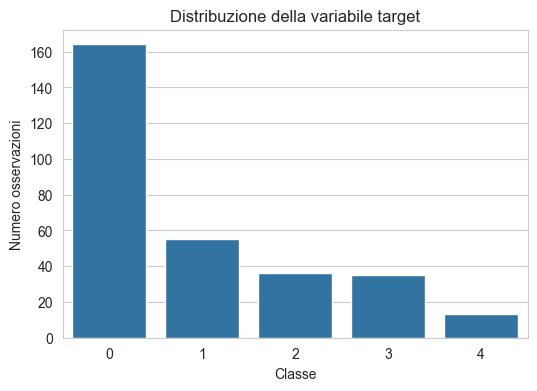

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["num"]
)

plt.title("Distribuzione della variabile target")
plt.xlabel("Classe")
plt.ylabel("Numero osservazioni")

plt.show()

### Considerazioni preliminari

Dall'analisi iniziale emerge che il dataset contiene 303 osservazioni e 13 variabili predittive.

La variabile target presenta cinque possibili valori compresi tra 0 e 4, che rappresentano differenti livelli di gravità della patologia cardiaca.

Nei successivi esperimenti il problema verrà trasformato in una classificazione binaria distinguendo esclusivamente tra presenza e assenza della malattia, come comunemente riportato nella letteratura scientifica relativa a questo dataset.

L'analisi dei valori mancanti consentirà inoltre di definire le opportune strategie di preprocessing da applicare prima dell'addestramento dei modelli di Machine Learning.